# Milestone 2 — Exploratory Data Analysis

Hangu outpatient oncology clinic consultation dataset.

This notebook only **describes** the raw data. No cleaning, imputation, or feature engineering is performed here — those are handled by later milestones (`ml.data.clean`, `ml.data.features`). All computations are delegated to the tested `ml.eda.summary` and `ml.eda.plots` modules so this notebook stays a thin, reproducible report rather than ad hoc analysis.

In [1]:
import logging

import pandas as pd
from IPython.display import Image, display

from ml.data.load import load_raw_data
from ml.eda.summary import (
    descriptive_stats,
    missing_value_report,
    patient_visit_report,
    service_time_summary,
    working_day_crosstab,
)
from ml.eda.plots import generate_all_eda_figures

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
pd.set_option("display.max_columns", None)

## 1. Load Raw Data

In [2]:
df = load_raw_data()
print(f"Shape: {df.shape}")
df.head()

INFO Loading raw dataset from /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/data/raw/Data.csv


INFO Loaded 6637 rows and 14 columns


INFO Schema validation passed: shape=(6637, 14), columns=14


Shape: (6637, 14)


,ID,Session,Month,DayOfWeek,WorkingDay,AM_PM,Visit.No,Gender,M.Cancer,S.Cancer,StartTime,PayTime,Address,ServTime
0,HAA052B7CD,1,January,Wednesday,True,morning,7,F,True,False,8:31:40,8:44:28,Out of city,691
1,HA18BDDC46,1,January,Wednesday,True,morning,6,F,False,False,8:43:11,9:07:31,In the city,614
2,HFC7DD5A0B,1,January,Wednesday,True,morning,2,F,False,False,8:53:25,9:08:38,NaN,559
3,HE10BEEB38,1,January,Wednesday,True,morning,2,M,False,False,9:02:44,9:15:13,Out of city,749
4,HBF11B62B6,1,January,Wednesday,True,morning,10,F,False,False,9:26:19,10:01:57,Out of city,450


## 2. Missing Values

`PayTime` and `Address` are the only columns with missing data. `Address` is missing for over a third of rows and will need an explicit missing-data strategy in Milestone 3 (cleaning) rather than silent imputation.

In [3]:
missing_value_report(df)

WARNING Columns with >30% missing values: ['Address']


,n_missing,pct_missing
Address,2392,36.04
PayTime,279,4.20
ID,0,0.00
Session,0,0.00
Month,0,0.00
DayOfWeek,0,0.00
WorkingDay,0,0.00
AM_PM,0,0.00
Visit.No,0,0.00
Gender,0,0.00


## 3. Descriptive Statistics (Numeric Columns)

In [4]:
descriptive_stats(df)

,count,mean,std,min,25%,50%,75%,max
Session,6637.0,193.669429,111.089056,1.0,96.0,194.0,292.0,381.0
Visit.No,6637.0,6.830646,15.588881,1.0,1.0,2.0,6.0,170.0
ServTime,6637.0,801.910954,372.913355,180.0,540.0,725.0,975.0,3457.0


## 4. Patient Visit Structure

Rows are **not independent observations** when the same patient has multiple visits. This must inform a grouped train/test split in Milestone 6.

In [5]:
patient_visit_report(df)

INFO 1192/2429 rows (49.1%) belong to patients with more than one visit


{'n_rows': 6637,
 'n_unique_patients': 2429,
 'n_repeat_patients': 1192,
 'max_visits_per_patient': 53,
 'mean_visits_per_patient': 2.7324001646768217}

## 5. Day of Week vs. Working Day

The clinic operates mainly Wednesday/Saturday. Saturday is usually a non-working day, but a subset of Saturdays are marked as working — consistent with compensatory working days around public holidays. `WorkingDay` therefore carries information beyond `DayOfWeek` alone.

WorkingDay,False,True
DayOfWeek,,
Friday,0,151
Saturday,3438,167
Tuesday,0,80
Wednesday,0,2801


WARNING Columns with >30% missing values: ['Address']


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_missingness.png


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_servtime_distribution.png


INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_servtime_by_dayofweek.png


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_workingday_heatmap.png


INFO Generated 7 EDA figures in /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures


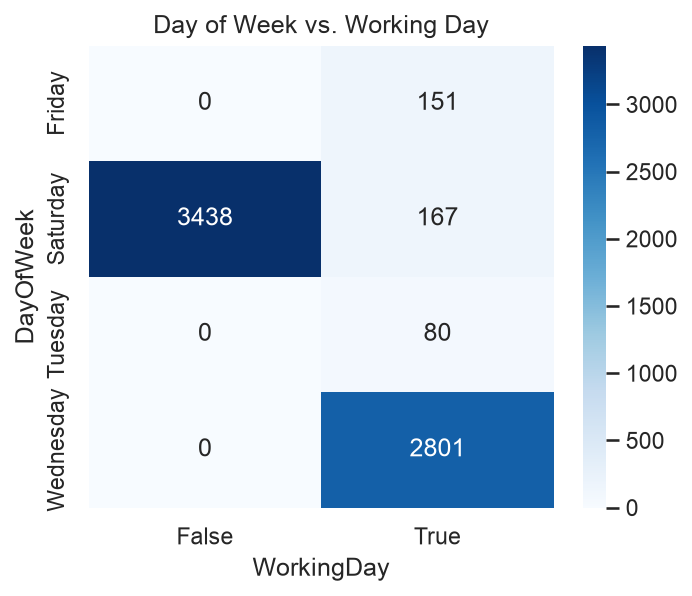

In [6]:
display(working_day_crosstab(df))
display(Image(generate_all_eda_figures(df)[-1]))

## 6. Consultation Duration (Regression/Classification Target Source)

`ServTime` is recorded in seconds and will be converted to minutes for modelling. The distribution is right-skewed with a long tail of longer consultations.

In [7]:
service_time_summary(df)

{'count': 6637,
 'mean_seconds': 801.9109537441615,
 'std_seconds': 372.9133547605661,
 'min_seconds': 180.0,
 'max_seconds': 3457.0,
 'mean_minutes': 13.365182562402692,
 'median_minutes': 12.083333333333334,
 'std_minutes': 6.215222579342768,
 'skew': 1.5732845389897259,
 'n_iqr_outliers': 218}

WARNING Columns with >30% missing values: ['Address']


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_missingness.png


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_servtime_distribution.png


INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_servtime_by_dayofweek.png


INFO Saved figure to /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures/eda_workingday_heatmap.png


INFO Generated 7 EDA figures in /Users/arianabutina/Desktop/Ariana . Project MADA/consult-time-ml/report/figures


eda_missingness.png


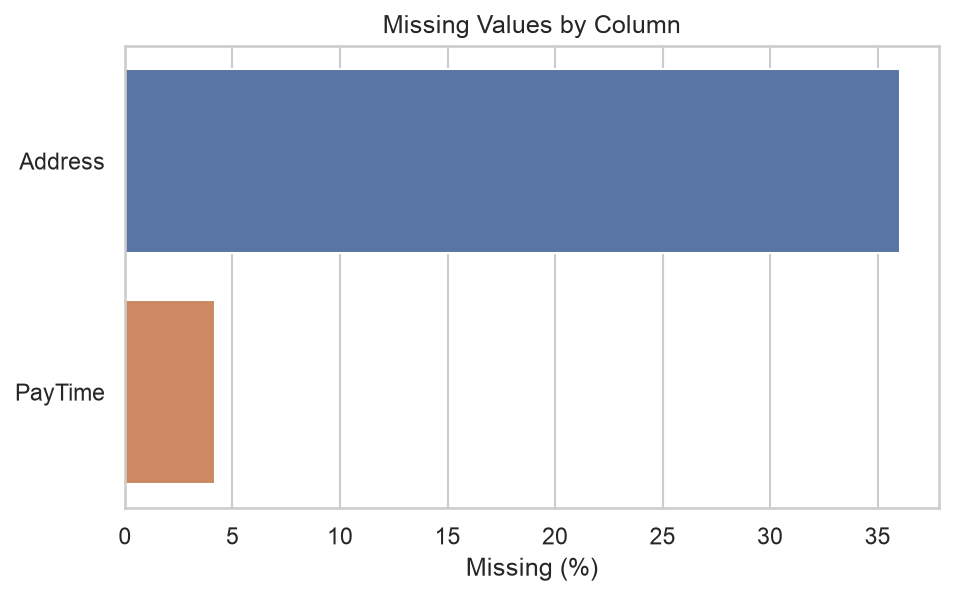

eda_servtime_distribution.png


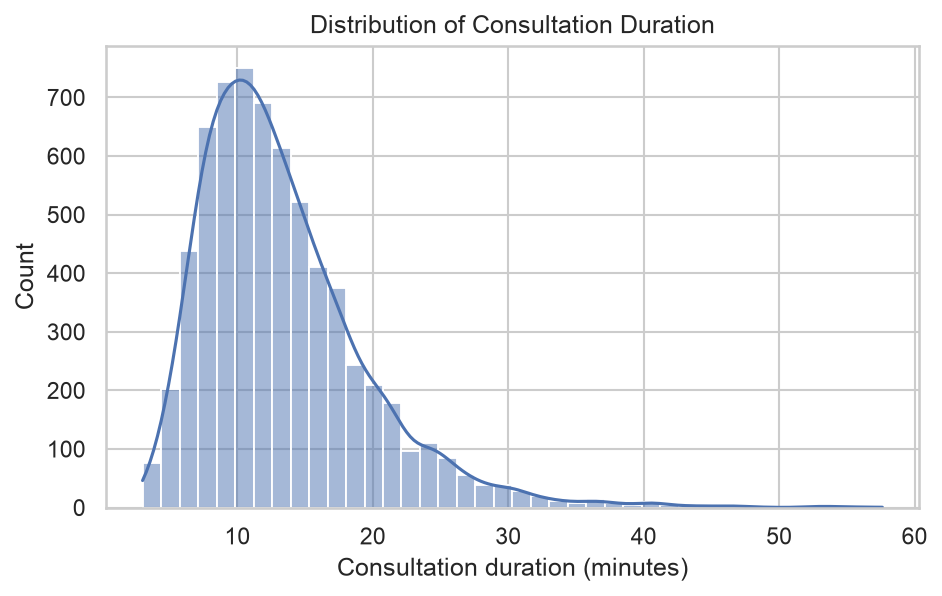

eda_counts_dayofweek.png


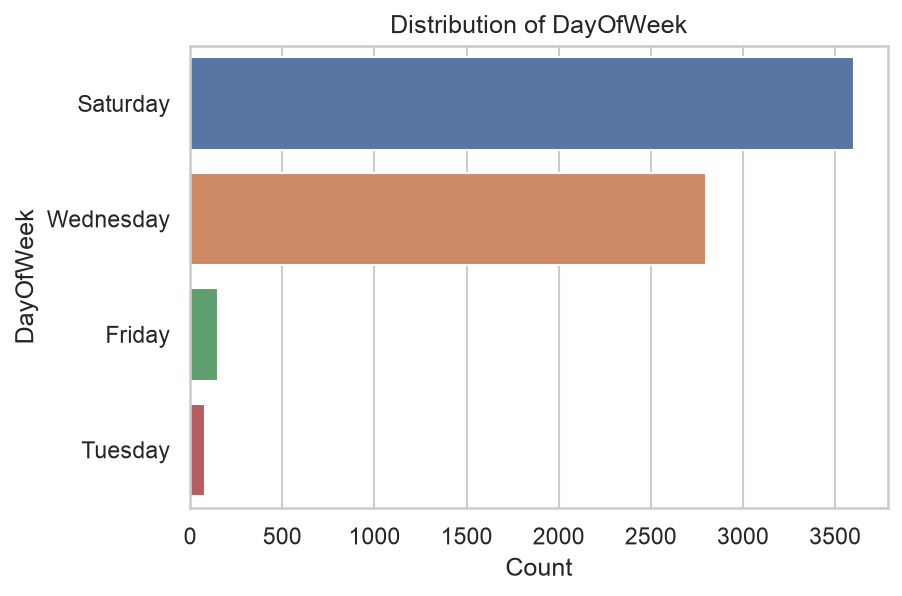

eda_counts_gender.png


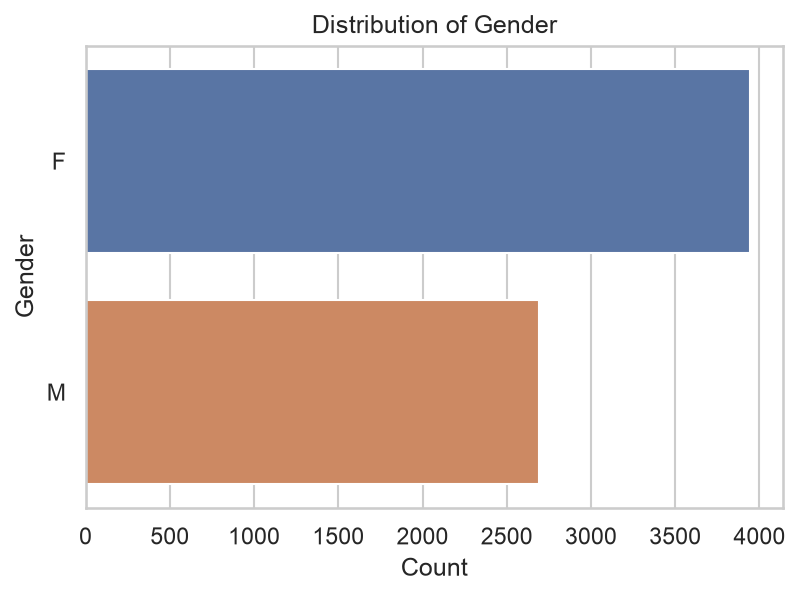

eda_counts_address.png


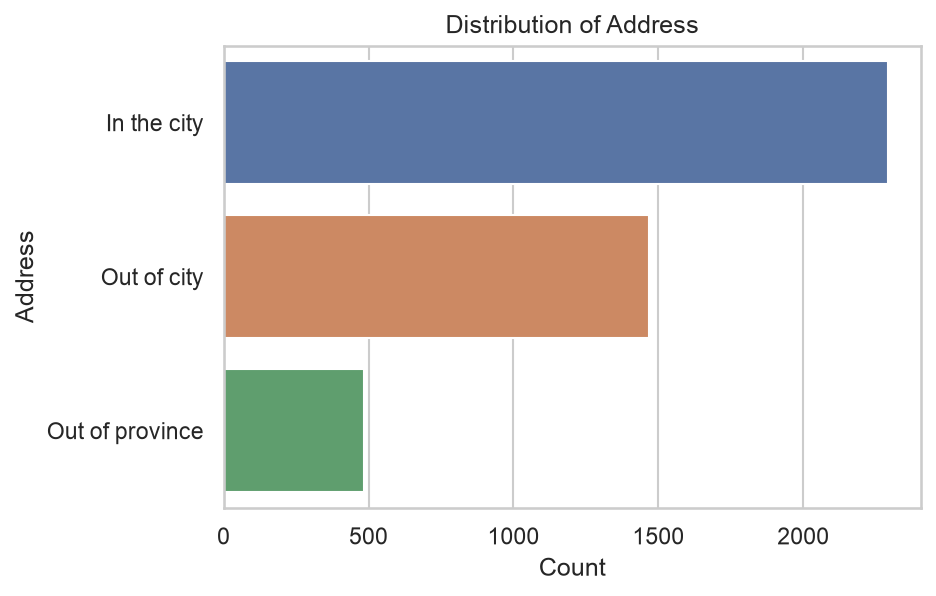

eda_servtime_by_dayofweek.png


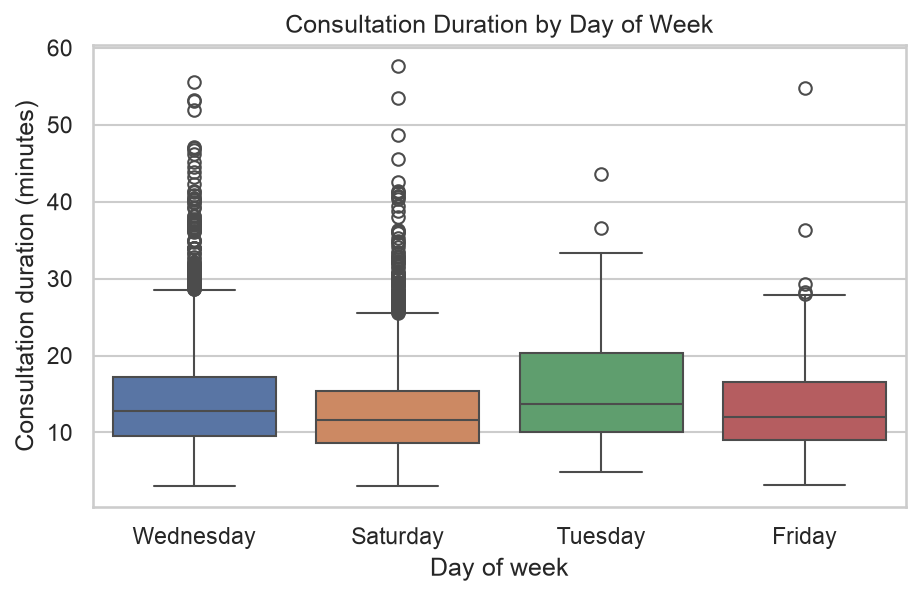

eda_workingday_heatmap.png


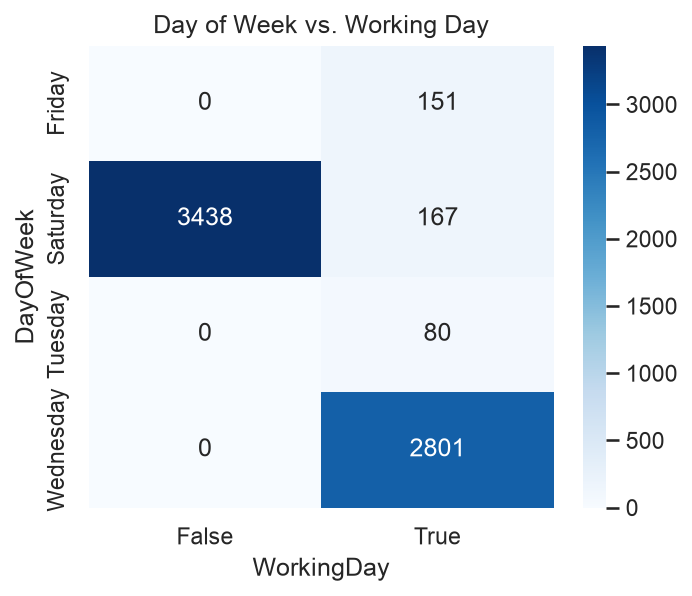

In [8]:
figures = generate_all_eda_figures(df)
for path in figures:
    print(path.name)
    display(Image(path))

## 7. Summary of Key Findings

- **6,637 rows, 14 columns**, no fully duplicated rows.
- **`Address`** missing in ~36% of rows; **`PayTime`** missing in ~4%.
- **2,429 unique patients**; repeat visits are common and must be handled with a grouped (patient-level) train/test split.
- **`DayOfWeek` is effectively 4 categories** (Wed/Sat dominate; Fri/Tue are rare), and **`WorkingDay`** captures a distinct compensatory-holiday signal not implied by `DayOfWeek` alone.
- **`ServTime`** (target source) is right-skewed, ranges 3–57.6 minutes, with a small number of IQR-based high-end outliers — worth discussing rather than silently dropping.
- **`M.Cancer`/`S.Cancer`** are boolean flags, not multi-level diagnosis categories; `S.Cancer` is rare (~1% True).

These findings directly inform the cleaning rules (Milestone 3) and feature engineering decisions (Milestone 4).